# LRA quality cutoffs — does any GCA-only genome match the GCF envelope?

We've already run CheckM2 uniformly across **5,557 unique biological assemblies** (Phase B). The annotated cohort lives in `lra_discovery.tsv` — one row per assembly, with sibling `GCA` / `GCF` columns, provenance booleans, and CheckM2 metrics.

**Question this notebook answers:** which of the **1,194 GCA-only** assemblies (no paired RefSeq) are good enough to include alongside the **4,363 GCF** assemblies (our curated baseline)?

Two tiers, plotted side-by-side:

- **GCF** — `scoring_accession` starts with `GCF_`. CheckM2 scored the RefSeq-curated version. **Blue**, α=0.6.
- **GCA** — `scoring_accession` starts with `GCA_`. CheckM2 scored the GenBank version (no paired RefSeq exists, or the paired GCF was suppressed). **Red**, α=0.5.

The decision rule (§7) draws percentile-based thresholds from the GCF tier — *that's the envelope of "reference-tier good"* — and counts how many GCAs sit inside it. Locked rule in §8.

**Inputs (no NCBI fetch, no `_data/` cache):** just `<RDS>/david/processed/lra_discovery.tsv` from Phase B.8.

## 0 · Parameters — edit these to re-tune the GCA-acceptance cutoff

`USE_GCF_PERCENTILE` controls how the four envelope thresholds (completeness, contamination, total_contigs, contig_n50) are drawn from the GCF tier's distribution (Table A in §6).

- `0` — empirical extreme. **Zero GCFs excluded by construction.** Most inclusive of GCAs.
- `1` or `2` — trim the worst 1 % / 2 % of GCFs from each tail. Tighter rule; excludes those GCF outliers too.

After iterating, record the locked value + thresholds in §8.

In [1]:
# ─── PARAMETERS ────────────────────────────────────────────────────────────
USE_GCF_PERCENTILE = 0    # 0 | 1 | 2 — % trimmed from each tail of GCF distribution
# ───────────────────────────────────────────────────────────────────────────

## 1 · Load `lra_discovery.tsv` — the single annotated source

Auto-detect: HPC canonical path first, then the local `_data/` cache (rsync'd copy for off-HPC dev).

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _first_existing(candidates):
    for c in candidates:
        p = Path(c)
        if p.exists():
            return p
    raise FileNotFoundError(f"None of: {candidates}")

# Notebook lives at src/bac_data/lr_data/notebooks/; sibling _data/ caches the HPC rsync.
REPO_ROOT = Path.cwd().resolve()
while REPO_ROOT.name and not (REPO_ROOT / "pyproject.toml").exists():
    REPO_ROOT = REPO_ROOT.parent

DISCOVERY_TSV = _first_existing([
    "/home/dca36/rds/rds-floto-bacterial-4k08a2yyQLw/david/processed/lra_discovery.tsv",
    REPO_ROOT / "src" / "bac_data" / "lr_data" / "notebooks" / "_data" / "lra_discovery.tsv",
])
print(f"DISCOVERY_TSV = {DISCOVERY_TSV}")

disc = pd.read_csv(DISCOVERY_TSV, sep="\t", low_memory=False)
# Coerce the boolean columns (round-tripped as strings).
for b in ["source_audit", "source_norway", "source_refseq_metadata",
          "is_refseq", "is_norway", "stale_refseq", "download_needed"]:
    disc[b] = disc[b].astype(str).str.lower().isin({"true", "1", "yes"})

print(f"rows: {len(disc)}   cols: {len(disc.columns)}")

DISCOVERY_TSV = /Users/davidabelson/developer/BacHGT/src/bac_data/lr_data/notebooks/_data/lra_discovery.tsv
rows: 5557   cols: 29


## 2 · Define tiers + cohort summary

Group on `scoring_accession`'s prefix:

- **GCF** (blue): we scored the RefSeq-curated FASTA. 4,363 expected.
- **GCA** (red): we scored the GenBank FASTA (no paired RefSeq, or RefSeq was suppressed). 1,194 expected.

Two rows are GCA-tier rescues: their GCF was suppressed in NCBI, but the paired GCA was still current — we scored that instead. They show up here as GCA-tier because that's what got scored.

In [3]:
disc["tier"] = np.where(disc["scoring_accession"].str.startswith("GCF_"), "GCF", "GCA")

# Tier palette: blue baseline, red candidates.
TIER_COLOURS = {
    "GCF": ("#1f77b4", 0.6),    # blue
    "GCA": ("#d62728", 0.5),    # red
}
TIER_ORDER = ["GCF", "GCA"]

print("=== Tier counts ===")
print(disc["tier"].value_counts().reindex(TIER_ORDER))

print("\n=== Source provenance per tier (multi-source rows counted in each) ===")
for t in TIER_ORDER:
    sub = disc[disc["tier"] == t]
    print(f"\n  {t}  (n={len(sub)}):")
    print(f"    source_audit            : {int(sub['source_audit'].sum())}")
    print(f"    source_norway           : {int(sub['source_norway'].sum())}")
    print(f"    source_refseq_metadata  : {int(sub['source_refseq_metadata'].sum())}")
    print(f"    is_norway               : {int(sub['is_norway'].sum())}")
    print(f"    is_refseq               : {int(sub['is_refseq'].sum())}")
    print(f"    stale_refseq            : {int(sub['stale_refseq'].sum())}")

print("\n=== assembly_level (where known — from audit/norway) ===")
lvl = disc.groupby(["tier", "level"], dropna=False).size().unstack(fill_value=0)
print(lvl)

=== Tier counts ===
tier
GCF    4363
GCA    1194
Name: count, dtype: int64

=== Source provenance per tier (multi-source rows counted in each) ===

  GCF  (n=4363):
    source_audit            : 1665
    source_norway           : 268
    source_refseq_metadata  : 3630
    is_norway               : 268
    is_refseq               : 3630
    stale_refseq            : 0

  GCA  (n=1194):
    source_audit            : 906
    source_norway           : 266
    source_refseq_metadata  : 281
    is_norway               : 266
    is_refseq               : 281
    stale_refseq            : 281

=== assembly_level (where known — from audit/norway) ===
level  Chromosome  Complete Genome  Contig  Scaffold   NaN
tier                                                      
GCA            10               87     804         5   288
GCF            80             1115     425        45  2698


## 3 · Per-metric histograms (GCF vs GCA overlaid)

Six CheckM2 metrics, GCF in blue and GCA in red. Two vertical dashed lines on each plot mark the GCF empirical envelope:

- **red dashed** — `worst GCF` (empirical extreme; cutoff at `USE_GCF_PERCENTILE=0`)
- **orange dashed** — `worst_1pct` (cutoff if we trim the worst 1 % of GCFs)

Eyeball: what fraction of the GCA distribution sits inside the blue envelope?

In [ ]:
# Direction-aware cutoff helper: which metrics are 'lower is worse' vs 'higher is worse'?
LOW_IS_WORST = {
    "checkm2_completeness":     True,   # low completeness  → bad → floor    (quantile p)
    "checkm2_contig_n50":       True,   # low N50           → bad → floor
    "checkm2_contamination":    False,  # high contamination→ bad → ceiling  (quantile 1-p)
    "checkm2_total_contigs":    False,  # high contig count → bad → ceiling
}

gcf_rows = disc[disc["tier"] == "GCF"]

def gcf_cutoff(col: str, trim_pct: float) -> float:
    """GCF envelope cutoff for `col` after trimming the worst `trim_pct`% of GCFs."""
    p = trim_pct / 100.0
    q = p if LOW_IS_WORST[col] else (1 - p)
    return float(gcf_rows[col].quantile(q))

def overlay_hist(col, *, log_x=False, bins=60, xlim=None, title=None):
    fig, ax = plt.subplots(figsize=(8, 4))
    for t in TIER_ORDER:
        vals = disc.loc[disc["tier"] == t, col].dropna()
        if vals.empty:
            continue
        colour, alpha = TIER_COLOURS[t]
        if log_x:
            vals = vals.loc[vals > 0]
            if vals.empty:
                continue
            edges = np.logspace(np.log10(vals.min()), np.log10(vals.max()), bins)
        elif xlim is not None:
            # Use a fixed bin grid clipped to xlim so the requested `bins` count
            # is honoured across the visible range (rather than spread over the
            # full data span, which can leave most bins outside the xlim).
            edges = np.linspace(xlim[0], xlim[1], bins + 1)
        else:
            edges = bins
        ax.hist(vals, bins=edges, alpha=alpha, color=colour, label=f"{t} (n={len(vals)})")

    if col in LOW_IS_WORST:
        worst    = gcf_cutoff(col, 0)
        worst_1p = gcf_cutoff(col, 1)
        ax.axvline(worst,    color="red",    linestyle="--", linewidth=1.4, alpha=0.9,
                   label=f"worst GCF = {worst:.4g}")
        ax.axvline(worst_1p, color="orange", linestyle="--", linewidth=1.4, alpha=0.9,
                   label=f"worst_1pct = {worst_1p:.4g}")

    if log_x:
        ax.set_xscale("log")
    if xlim:
        ax.set_xlim(*xlim)
    ax.set_xlabel(col)
    ax.set_ylabel("count")
    ax.set_title(title or col)
    ax.legend(loc="best", fontsize=8)
    fig.tight_layout()
    plt.show()

overlay_hist("checkm2_completeness",  bins=20, xlim=(90, 100),  title="CheckM2 completeness (zoomed 90–100, 0.5% bins)")
overlay_hist("checkm2_contamination", bins=80, xlim=(0, 10),    title="CheckM2 contamination (zoomed 0–10)")
overlay_hist("checkm2_contig_n50",    log_x=True,               title="CheckM2 contig_n50 (log)")
overlay_hist("checkm2_total_contigs", log_x=True,               title="CheckM2 total_contigs (log)")
overlay_hist("checkm2_gc_content",    bins=80,                  title="CheckM2 GC content (informational; 2-decimal; see lra_GC_per_gene.ipynb for 3-decimal)")
overlay_hist("checkm2_genome_size",   bins=80,                  title="CheckM2 genome size (informational; no cutoff)")

## 4 · Bivariate scatter — `total_contigs` vs `contig_n50`

Cleanly assembled genomes sit in the top-left (few contigs, high N50). The further down-right a point, the more fragmented.

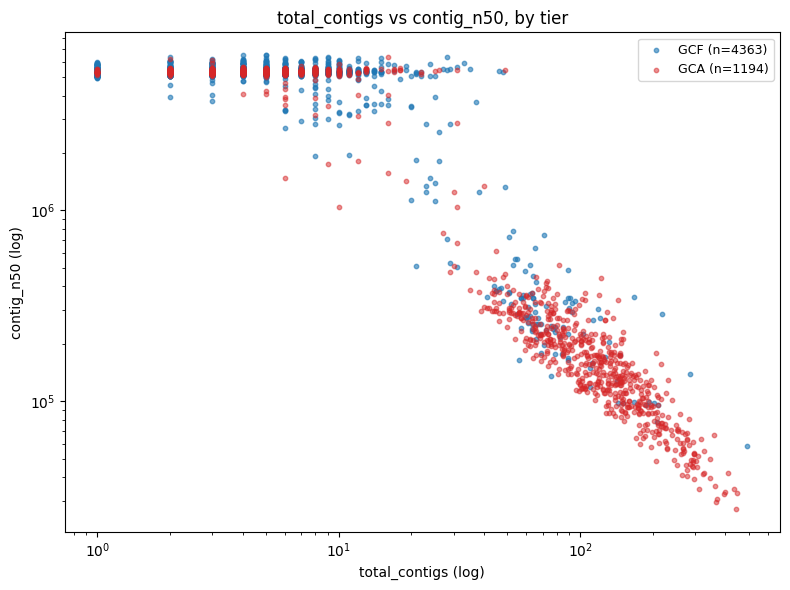

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))
for t in TIER_ORDER:
    sub = disc.loc[disc["tier"] == t].dropna(subset=["checkm2_total_contigs", "checkm2_contig_n50"])
    colour, alpha = TIER_COLOURS[t]
    ax.scatter(sub["checkm2_total_contigs"], sub["checkm2_contig_n50"],
               s=10, alpha=alpha, color=colour, label=f"{t} (n={len(sub)})")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("total_contigs (log)")
ax.set_ylabel("contig_n50 (log)")
ax.set_title("total_contigs vs contig_n50, by tier")
ax.legend(loc="best", fontsize=9)
fig.tight_layout()
plt.show()

## 5 · Contamination vs completeness — species outliers

A genome with low completeness or high contamination is suspect regardless of the contig stats. Far-corner points are the ones to drop.

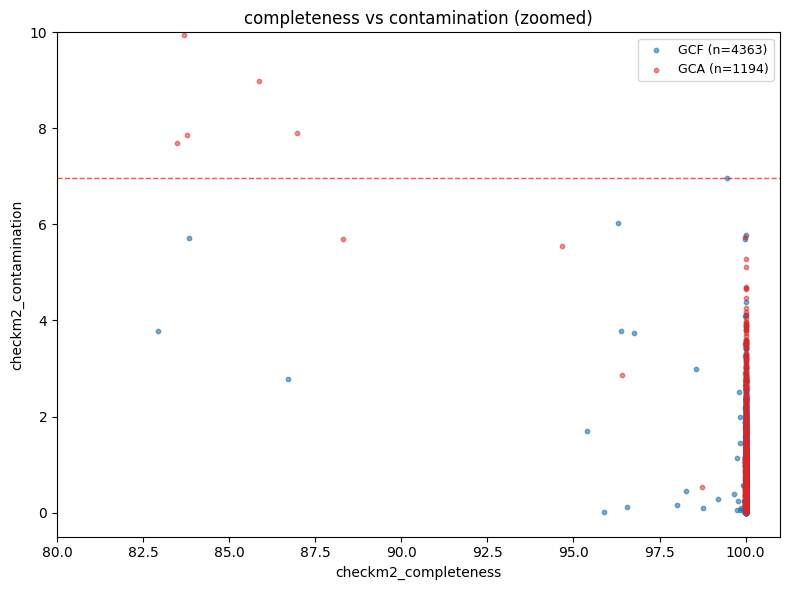

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))
for t in TIER_ORDER:
    sub = disc.loc[disc["tier"] == t].dropna(subset=["checkm2_completeness", "checkm2_contamination"])
    colour, alpha = TIER_COLOURS[t]
    ax.scatter(sub["checkm2_completeness"], sub["checkm2_contamination"],
               s=10, alpha=alpha, color=colour, label=f"{t} (n={len(sub)})")
ax.set_xlim(80, 101)
ax.set_ylim(-0.5, 10)
ax.set_xlabel("checkm2_completeness")
ax.set_ylabel("checkm2_contamination")
ax.set_title("completeness vs contamination (zoomed)")
ax.axvline(gcf_cutoff("checkm2_completeness", 0),  color="red",    linestyle="--", lw=1, alpha=0.7)
ax.axhline(gcf_cutoff("checkm2_contamination", 0), color="red",    linestyle="--", lw=1, alpha=0.7)
ax.legend(loc="best", fontsize=9)
fig.tight_layout()
plt.show()

## 6 · Table A — GCF cutoff candidates (direction-aware)

Per-metric thresholds drawn from the GCF distribution at three plausible values of `USE_GCF_PERCENTILE`:

- **`worst`** — the empirical extreme. Cutoff if we exclude **nothing** from the GCF baseline. For `completeness` / `contig_n50` this is the minimum; for `contamination` / `total_contigs` it's the maximum.
- **`worst_1pct`** — cutoff after dropping the **worst 1 %** of GCFs.
- **`worst_2pct`** — cutoff after dropping the **worst 2 %** of GCFs.

The red and orange dashed lines on the §3 histograms correspond to `worst` and `worst_1pct` respectively, so you can eyeball where the cutoff sits in each distribution.

In [7]:
TRIM_PCTS = [0, 1, 2]
ROW_LABELS = ["worst", "worst_1pct", "worst_2pct"]

table_a = pd.DataFrame(
    {col: [gcf_cutoff(col, p) for p in TRIM_PCTS] for col in LOW_IS_WORST},
    index=ROW_LABELS,
).round(2)

table_a.columns = [
    f"{c}\n({'≥ floor' if LOW_IS_WORST[c] else '≤ ceiling'})"
    for c in table_a.columns
]

print(f"=== Table A — GCF cutoff candidates (n={len(gcf_rows)} GCFs in envelope) ===\n")
display(table_a)

=== Table A — GCF cutoff candidates (n=4363 GCFs in envelope) ===



,checkm2_completeness\n(≥ floor),checkm2_contig_n50\n(≥ floor),checkm2_contamination\n(≤ ceiling),checkm2_total_contigs\n(≤ ceiling)
worst,78.70,58147.00,6.96,494.0
worst_1pct,99.99,262551.44,2.73,72.0
worst_2pct,99.99,492503.36,2.20,51.0


## 6a · Resolve thresholds at the chosen `USE_GCF_PERCENTILE`

By construction, percentile=0 excludes zero GCFs. Bumping to 1 or 2 trims the most extreme GCF outliers (and excludes them too — see §7's accept/reject column for GCF tier).

In [8]:
assert 0 <= USE_GCF_PERCENTILE < 50, "USE_GCF_PERCENTILE should be in [0, 50)"

MIN_COMPLETENESS  = gcf_cutoff("checkm2_completeness",  USE_GCF_PERCENTILE)
MAX_CONTAMINATION = gcf_cutoff("checkm2_contamination", USE_GCF_PERCENTILE)
MAX_TOTAL_CONTIGS = gcf_cutoff("checkm2_total_contigs", USE_GCF_PERCENTILE)
MIN_CONTIG_N50    = gcf_cutoff("checkm2_contig_n50",    USE_GCF_PERCENTILE)

print(f"USE_GCF_PERCENTILE = {USE_GCF_PERCENTILE}  (trim worst {USE_GCF_PERCENTILE}% of GCFs)")
print(f"  MIN_COMPLETENESS  ≥ {MIN_COMPLETENESS:.2f}")
print(f"  MAX_CONTAMINATION ≤ {MAX_CONTAMINATION:.2f}")
print(f"  MAX_TOTAL_CONTIGS ≤ {MAX_TOTAL_CONTIGS:.0f}")
print(f"  MIN_CONTIG_N50    ≥ {MIN_CONTIG_N50:.0f}")

USE_GCF_PERCENTILE = 0  (trim worst 0% of GCFs)
  MIN_COMPLETENESS  ≥ 78.70
  MAX_CONTAMINATION ≤ 6.96
  MAX_TOTAL_CONTIGS ≤ 494
  MIN_CONTIG_N50    ≥ 58147


## 7 · Apply the rule — Table B (per-tier exclusions)

Rule, in order (first failing criterion wins as the rejection reason):

```
if completeness     < MIN_COMPLETENESS   → reject
elif contamination  > MAX_CONTAMINATION  → reject
elif total_contigs  > MAX_TOTAL_CONTIGS  → reject
elif contig_n50     < MIN_CONTIG_N50     → reject
else → accept
```

Tables reported below:

- **Table B-1** — per-criterion exclusion counts, split by tier.
- **Table B-2** — accept vs reject totals per tier + accept rate. The headline answer is: **how many of the 1,194 GCAs fall inside the GCF envelope?**
- **Sample** — 20 randomly rejected GCA candidates so you can eyeball what's being excluded.

In [9]:
def classify(row):
    """Apply the GCF-envelope rule; return (accept_bool, reason_str)."""
    if pd.isna(row["checkm2_completeness"]):
        return False, "no_checkm2"
    if row["checkm2_completeness"] < MIN_COMPLETENESS:
        return False, "completeness"
    if row["checkm2_contamination"] > MAX_CONTAMINATION:
        return False, "contamination"
    if row["checkm2_total_contigs"] > MAX_TOTAL_CONTIGS:
        return False, "total_contigs"
    if row["checkm2_contig_n50"] < MIN_CONTIG_N50:
        return False, "contig_n50"
    return True, "accept"

verdicts = disc.apply(classify, axis=1, result_type="expand")
verdicts.columns = ["accept", "reason"]
disc_v = pd.concat([disc, verdicts], axis=1)

# Table B-1 — per-criterion exclusion counts × tier.
print("=== Table B-1 — exclusions by criterion × tier ===")
b1 = (
    disc_v.loc[~disc_v["accept"]]
          .groupby(["tier", "reason"]).size().unstack(fill_value=0)
          .reindex(index=TIER_ORDER)
          .reindex(columns=["no_checkm2", "completeness", "contamination",
                            "total_contigs", "contig_n50"], fill_value=0)
)
b1["TOTAL_REJECTED"] = b1.sum(axis=1)
b1["tier_n"] = disc_v.groupby("tier").size().reindex(TIER_ORDER).values
display(b1)

# Table B-2 — accept / reject totals + accept rate.
print("\n=== Table B-2 — accept vs reject per tier ===")
b2 = (
    disc_v.groupby(["tier", "accept"]).size().unstack(fill_value=0)
          .reindex(index=TIER_ORDER)
          .rename(columns={True: "accept", False: "reject"})
)
b2["total"]       = b2["accept"] + b2["reject"]
b2["accept_rate"] = (b2["accept"] / b2["total"]).round(3)
display(b2)

# Headline answer: how many GCA candidates pass?
n_gca_accept = int(((disc_v["tier"] == "GCA") & disc_v["accept"]).sum())
n_gca_total  = int((disc_v["tier"] == "GCA").sum())
print(f"\nHeadline: {n_gca_accept} of {n_gca_total} GCA candidates pass the GCF envelope "
      f"({100 * n_gca_accept / max(n_gca_total, 1):.1f}%).")

# Sample of rejected GCA rows — what's being discarded?
print("\n=== Sample (n=20) of REJECTED GCA-tier rows ===")
rej_gca = disc_v[(disc_v["tier"] == "GCA") & (~disc_v["accept"])]
if len(rej_gca):
    display(
        rej_gca.sample(min(20, len(rej_gca)), random_state=0)[[
            "scoring_accession", "reason",
            "checkm2_completeness", "checkm2_contamination",
            "checkm2_total_contigs", "checkm2_contig_n50",
            "is_norway", "is_refseq", "stale_refseq", "level",
        ]]
    )

=== Table B-1 — exclusions by criterion × tier ===


reason,no_checkm2,completeness,contamination,total_contigs,contig_n50,TOTAL_REJECTED,tier_n
tier,,,,,,,
GCF,0,NaN,NaN,0,NaN,0.0,4363
GCA,0,1.0,10.0,0,44.0,55.0,1194



=== Table B-2 — accept vs reject per tier ===


accept,reject,accept,total,accept_rate
tier,,,,
GCF,0,4363,4363,1.000
GCA,55,1139,1194,0.954



Headline: 1139 of 1194 GCA candidates pass the GCF envelope (95.4%).

=== Sample (n=20) of REJECTED GCA-tier rows ===


,scoring_accession,reason,checkm2_completeness,checkm2_contamination,checkm2_total_contigs,checkm2_contig_n50,is_norway,is_refseq,stale_refseq,level
1142,GCA_947662245.2,completeness,76.49,5.48,5,5352577,False,False,False,Complete Genome
354,GCA_023452725.1,contig_n50,100.00,0.42,442,27137,False,False,False,Contig
534,GCA_026322515.1,contig_n50,100.00,1.66,347,39376,False,False,False,Contig
310,GCA_023368295.1,contig_n50,100.00,3.04,393,32600,False,False,False,Contig
194,GCA_023040795.1,contig_n50,100.00,2.30,290,45959,False,False,False,Contig
99,GCA_023036135.1,contig_n50,100.00,0.14,297,52608,False,False,False,Contig
351,GCA_023452375.1,contig_n50,100.00,0.92,264,41143,False,False,False,Contig
563,GCA_029492185.1,contig_n50,100.00,0.58,244,48916,False,False,False,Contig
1143,GCA_947662735.2,contamination,85.87,8.98,4,5265078,False,False,False,Complete Genome
331,GCA_023407915.1,contig_n50,100.00,1.91,289,49302,False,False,False,Contig


## 7a · Pre-write the accepted-LRA set (preview)

Once you've locked the percentile in §8, `build_lra_set.py` (Phase E) emits this same accept-list as a TSV under `<RDS>/david/processed/lra_set.tsv`. Here's the preview-table the module would produce.

In [10]:
preview_cols = [
    "scoring_accession", "tier", "GCA", "GCF", "Sample", "related_lr_run_accession",
    "level", "is_refseq", "is_norway", "stale_refseq",
    "checkm2_completeness", "checkm2_contamination",
    "checkm2_total_contigs", "checkm2_contig_n50",
    "checkm2_genome_size", "checkm2_gc_content",
    "reason",
]
accepted = disc_v[disc_v["accept"]][preview_cols].copy()
print(f"accepted: {len(accepted)} rows  (GCF={(accepted['tier']=='GCF').sum()}  /  GCA={(accepted['tier']=='GCA').sum()})")
display(accepted.head(15))

accepted: 5502 rows  (GCF=4363  /  GCA=1139)


,scoring_accession,tier,GCA,GCF,Sample,related_lr_run_accession,level,is_refseq,is_norway,stale_refseq,checkm2_completeness,checkm2_contamination,checkm2_total_contigs,checkm2_contig_n50,checkm2_genome_size,checkm2_gc_content,reason
0,GCA_013733775.1,GCA,GCA_013733775.1,NaN,SAMN15148673,SRR12298692,Complete Genome,False,False,False,100.0,0.30,8,5672105,5996058,0.56,accept
1,GCA_013737205.1,GCA,GCA_013737205.1,NaN,SAMN15148619,SRR12298779,Complete Genome,False,False,False,100.0,1.35,10,5853583,6758354,0.55,accept
2,GCA_013737895.1,GCA,GCA_013737895.1,NaN,SAMN15148609,SRR12298814,Complete Genome,False,False,False,100.0,0.68,7,5721466,6268110,0.56,accept
3,GCA_013747515.1,GCA,GCA_013747515.1,NaN,SAMN15148647,SRR12298720,Complete Genome,False,False,False,100.0,0.57,3,5922729,6172560,0.56,accept
4,GCA_013751295.1,GCA,GCA_013751295.1,NaN,SAMN15148592,SRR12298833,Complete Genome,False,False,False,100.0,1.84,3,6105667,6425524,0.56,accept
5,GCA_013784845.1,GCA,GCA_013784845.1,NaN,SAMN15148636,SRR12298734,Complete Genome,False,False,False,100.0,0.79,2,6210043,6384090,0.56,accept
6,GCA_015719685.2,GCA,GCA_015719685.2,NaN,SAMN10435770,SRR35556785,Contig,False,False,False,100.0,0.91,3,5431435,5639638,0.57,accept
7,GCA_015719895.2,GCA,GCA_015719895.2,NaN,SAMN11285817,SRR35556834,Contig,False,False,False,100.0,0.79,6,5493500,5667606,0.57,accept
8,GCA_015719905.2,GCA,GCA_015719905.2,NaN,SAMN10435759,SRR35903307,Contig,False,False,False,100.0,0.80,5,4227069,5660167,0.57,accept
9,GCA_015720015.2,GCA,GCA_015720015.2,NaN,SAMN10435757,SRR35556868,Complete Genome,False,False,False,100.0,0.80,2,5490374,5655586,0.57,accept


## 8 · Locked decision — paste into `build_lra_set.py`

Once happy with the thresholds above, fill in the values below for future readers, then copy them into the Phase E module.

**LRA acceptance rule (LOCKED):** _fill in after iterating on §0_

- `USE_GCF_PERCENTILE = …`

Resolved thresholds (printed by §6a):

- `MIN_COMPLETENESS  ≥ …`
- `MAX_CONTAMINATION ≤ …`
- `MAX_TOTAL_CONTIGS ≤ …`
- `MIN_CONTIG_N50    ≥ …`

**Accepted set size:** _GCF accepted + GCA accepted = N_ (from §7 Table B-2)

**Rationale:** _one paragraph — why this percentile, what the rejected-GCA sample looked like, anything surprising in the §3 distributions._